In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error, median_absolute_error, explained_variance_score, max_error

inputs: signal, split_point
outputs: signal_train, signal_test, threshold vs r2 curve, best threshold, best r2, pred curve, eval metrics

In [40]:
def blackbox(signal):
    signal_train = signal[0:len(signal) // 2]
    signal_test = signal[len(signal) // 2:]
    
    plt.figure()
    plt.plot(signal_train)
    plt.title("Train signal")

    plt.figure()
    plt.plot(signal_test)
    plt.title("Test signal")

    Y_fft = np.fft.fft(signal_train)
    freqs = np.fft.fftfreq(len(signal_train), 1)
    pos_mask = freqs >= 0
    Y_fft_pos = Y_fft[pos_mask]
    freqs_pos = freqs[pos_mask]
    plt.figure()
    plt.plot(freqs, Y_fft)
    plt.title("Frequency vs Strength curve")
    

    r2_scores = []
    max_score = 0
    best_threshold = 0
    for i in np.arange(0,1,0.001):
        threshold = i
        lpf_mask = np.abs(freqs) < threshold
        Y_fft_lpf = Y_fft * lpf_mask
        y_time_domain = np.fft.ifft(Y_fft_lpf).real
        r_score   = r2_score(signal_test, y_time_domain)
        r2_scores.append(r_score)
        if r_score > max_score:
            max_score = r_score
            best_threshold = i
    print("Best Threshold Frequency: ", best_threshold)
    print("Best R2 value: ", max_score)
    plt.figure()
    plt.plot(np.arange(0,1,0.001), r2_scores)
    plt.title("Threshold vs R2 Score curve")

    lpf_mask = np.abs(freqs) < best_threshold
    Y_fft_lpf = Y_fft * lpf_mask
    freqs_lpf = freqs * lpf_mask
    plt.figure()
    plt.plot(freqs_lpf, Y_fft_lpf)
    plt.title("Frequency vs Strength (LPF) curve")
    plt.xlim(-1 * best_threshold - 0.1, best_threshold + 0.1)

    y_time_domain = np.fft.ifft(Y_fft_lpf).real
    plt.figure()
    plt.plot(y_time_domain)
    plt.title("Reconstructed prediction curve")

    
    def regression_comparison_table(y_true, y_dnn, y_opt):
    
        def compute_metrics(y_true, y_pred):
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae  = mean_absolute_error(y_true, y_pred)
            r2   = r2_score(y_true, y_pred)
            medae = median_absolute_error(y_true, y_pred)
            evs = explained_variance_score(y_true, y_pred)
            maxe = max_error(y_true, y_pred)
    
            return {
                "RMSE": rmse,
                "MAE": mae,
                "R2": r2,
                "MedAE": medae,
                "ExplainedVariance": evs,
                "MaxError": maxe
            }
    
        dnn_metrics = compute_metrics(y_true, y_dnn)
        opt_metrics = compute_metrics(y_true, y_opt)
    
        print("\nRegression Model Comparison\n")
    
        header = f"{'Metric':<20}{'DNN':>15}{'Optimizer':>15}"
        print(header)
        print("-" * len(header))
    
        for key in dnn_metrics:
            print(f"{key:<20}{dnn_metrics[key]:>15.6f}{opt_metrics[key]:>15.6f}", '             ', np.abs(dnn_metrics[key] - opt_metrics[key]))
    
        return dnn_metrics, opt_metrics

    generate_metrics = regression_comparison_table(signal_test, signal_train, y_time_domain)

    

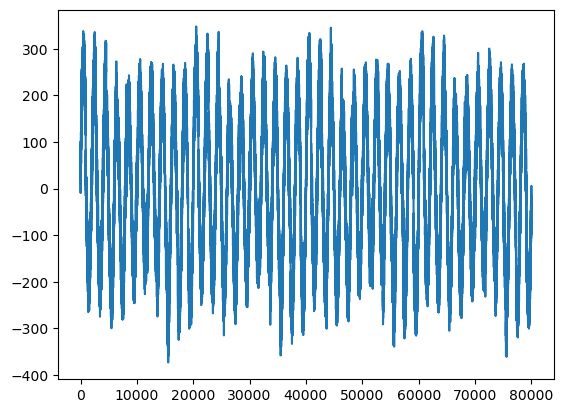

In [50]:
#setting up time array and random seed
domain = 8000
step = 0.1
t = np.arange(0, domain, step)

np.random.seed(42)

#setting up feature functions and adding random gaussian noise
noise_mf = 10
x1c = 210
x2c = 19
x3c = 100
x4c = 22
x1 = 210 * np.sin(2 * 3.14 * 0.005 * t) + 12 * np.cos(2 * 3.14 * 0.001 * t) + np.random.normal(0,x1c * noise_mf / 100, size=t.shape)

x2 = 19 * np.sign(np.sin(2 * np.pi * 0.001 * t)) + np.random.normal(0, x2c * noise_mf / 100, size=t.shape)

x3 = 100 * (t * 0.0055 - np.floor(0.5 + t * 0.0055)) + np.random.normal(0, x3c * noise_mf / 100, size=t.shape)

x4 = 22 * np.arcsin(np.sin(2 * np.pi * 0.0025 * t)) / np.pi + np.random.normal(0, x4c * noise_mf / 100, size=t.shape)

x5 = np.random.normal(1, 5, size=t.shape) #dc offset

#setting up the label curve
def generate_signal(t):

    # Initialize signal array
    y = np.zeros_like(t)

    # Lag-1 dependency: start from index 1
    y[1:] = x1[:-1] + x2[:-1] + x3[:-1] + x4[:-1] + x5[:-1]

    # Optional: first value can be set to 0 or same as t=0
    y[0] = x1[0] + x2[0] + x3[0] + x4[0] + x5[0]

    return y

#creating signal by reversing and replicating generated base curve
signal = generate_signal(t)
plt.plot(signal)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Best Threshold Frequency:  0.015
Best R2 value:  0.9722762587623193

Regression Model Comparison

Metric                          DNN      Optimizer
--------------------------------------------------
RMSE                      35.216518      26.335296               8.881221700973352
MAE                       28.100005      21.006203               7.093801999822627
R2                         0.950424       0.972276               0.021851889306903294
MedAE                     23.755967      17.750281               6.005686340795222
ExplainedVariance          0.950426       0.972277               0.021851889306903294
MaxError                 155.229821     124.677423               30.552398073426815


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


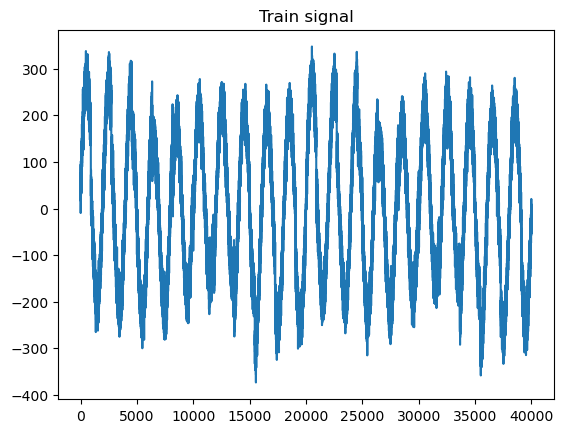

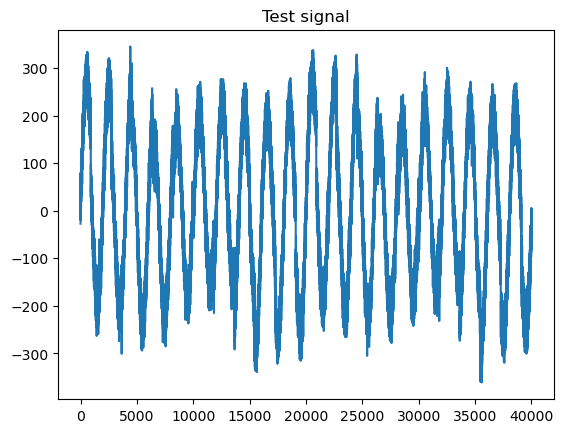

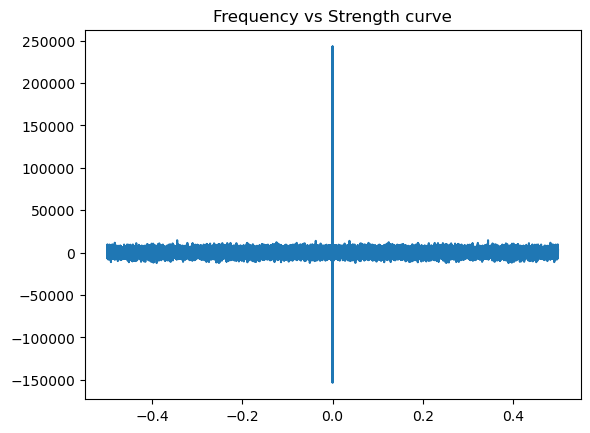

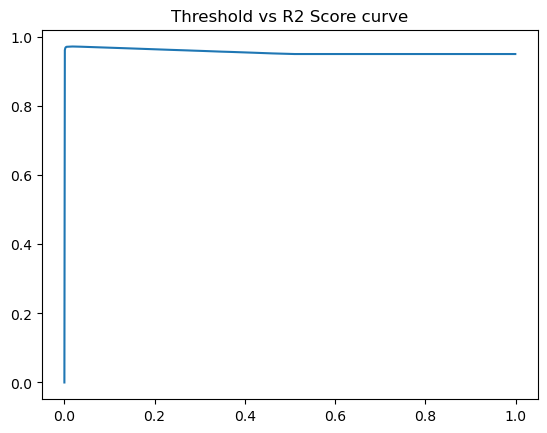

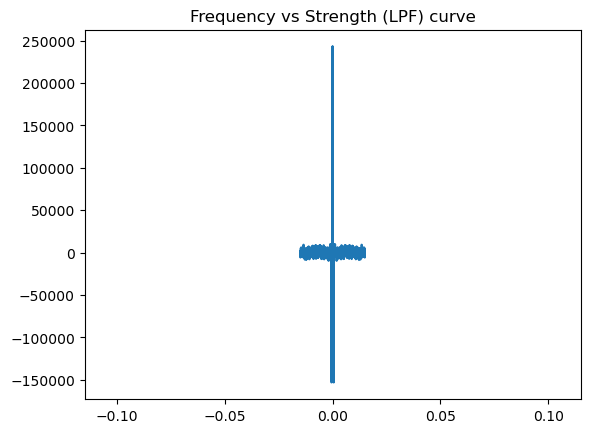

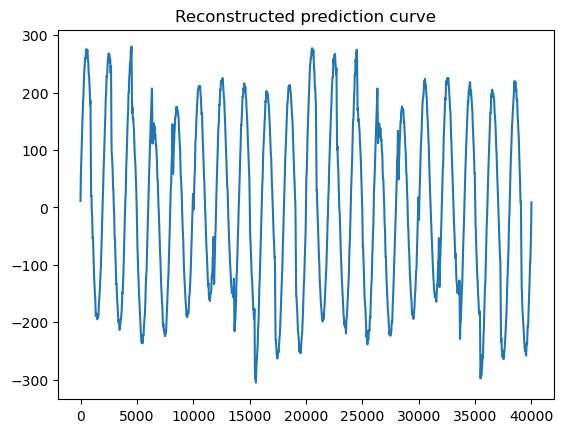

In [52]:
analysis = blackbox(signal)

(0.0, 10.0)

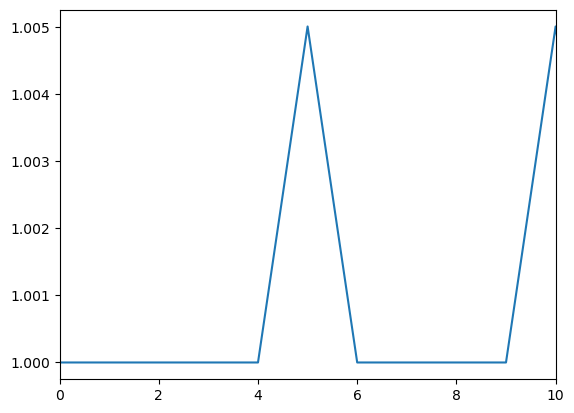

In [103]:
plt.plot(np.exp(np.mod(t, 0.005)))
plt.xlim(0,10)